
**Import Libraries**

In [28]:
import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing import image



**Mount Google Drive**

In [29]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Extract Dataset**

In [30]:
zip_path = "/content/drive/MyDrive/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting")

Done extracting


In [31]:
for root, dirs, files in os.walk("/content/dataset"):
    print(root)

/content/dataset
/content/dataset/dataset
/content/dataset/dataset/images
/content/dataset/dataset/images/skirt
/content/dataset/dataset/images/shirts
/content/dataset/dataset/images/pants
/content/dataset/dataset/images/watches
/content/dataset/dataset/images/bags
/content/dataset/dataset/images/outfit
/content/dataset/dataset/images/shoes


**Show Sample Images**

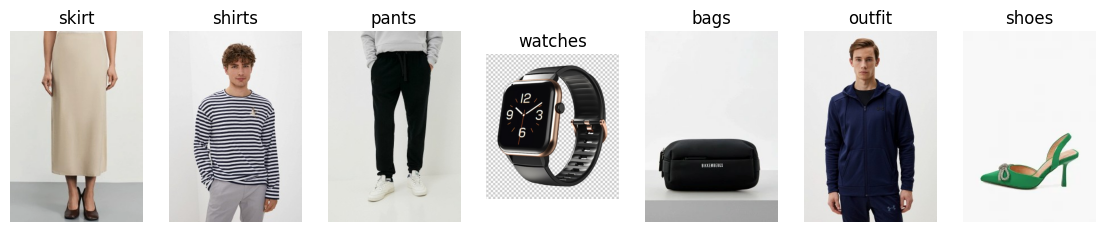

In [32]:
base_path = "/content/dataset/dataset/images"

classes = os.listdir(base_path)

plt.figure(figsize=(14, 6))

for i, class_name in enumerate(classes):
    class_path = os.path.join(base_path, class_name)

    if not os.path.isdir(class_path):
        continue

    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(class_name)

plt.show()

**Data Cleaning**

In [33]:
import shutil
import hashlib

bad_dir = "/content/cleaning_removed/bad_images"
duplicate_dir = "/content/cleaning_removed/duplicate_images"

os.makedirs(bad_dir, exist_ok=True)
os.makedirs(duplicate_dir, exist_ok=True)

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

total_files = 0
bad_files = 0
duplicate_files = 0
valid_images = 0

image_hashes = {}

def safe_move(src, dst_folder):
    filename = os.path.basename(src)
    name, ext = os.path.splitext(filename)
    dst = os.path.join(dst_folder, filename)

    counter = 1
    while os.path.exists(dst):
        dst = os.path.join(dst_folder, f"{name}_{counter}{ext}")
        counter += 1

    shutil.move(src, dst)

# Define base_image_dir using the path from previous cells
base_image_dir = "/content/dataset/dataset/images"

for root, dirs, files in os.walk(base_image_dir):
    for file in files:
        total_files += 1
        file_path = os.path.join(root, file)

        if not os.path.exists(file_path):
            continue

        # 1) إزالة الملفات اللي مش صور
        if not file.lower().endswith(valid_extensions):
            safe_move(file_path, bad_dir)
            bad_files += 1
            continue

        # 2) إزالة الصور التالفة
        try:
            with Image.open(file_path) as img:
                img.verify()
        except:
            safe_move(file_path, bad_dir)
            bad_files += 1
            continue

        # 3) إزالة الصور المكررة
        try:
            with open(file_path, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            if file_hash in image_hashes:
                safe_move(file_path, duplicate_dir)
                duplicate_files += 1
                continue
            else:
                image_hashes[file_hash] = file_path
                valid_images += 1

        except:
            safe_move(file_path, bad_dir)
            bad_files += 1

print("Cleaning Finished")
print("-----------------")
print("Total files checked:", total_files)
print("Valid images:", valid_images)
print("Bad files moved:", bad_files)
print("Duplicate images moved:", duplicate_files)

Cleaning Finished
-----------------
Total files checked: 1210
Valid images: 1182
Bad files moved: 0
Duplicate images moved: 28


**Check Dataset Classes**

In [34]:
for class_name in os.listdir(base_image_dir):
    class_path = os.path.join(base_image_dir, class_name)

    if os.path.isdir(class_path):
        num_images = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(valid_extensions)
        ])
        print(class_name, ":", num_images)

skirt : 156
shirts : 167
pants : 166
watches : 101
bags : 204
outfit : 191
shoes : 197


**Load and Split Dataset**

In [35]:
img_size = (224, 224)
batch_size = 32
validation_split = 0.2

train_ds = tf.keras.utils.image_dataset_from_directory(
    base_image_dir,
    validation_split=validation_split,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_image_dir,
    validation_split=validation_split,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 1182 files belonging to 7 classes.
Using 946 files for training.
Found 1182 files belonging to 7 classes.
Using 236 files for validation.
Classes: ['bags', 'outfit', 'pants', 'shirts', 'shoes', 'skirt', 'watches']
Number of classes: 7


**Optimize Dataset Loading**

In [36]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [37]:
import json

with open("/content/drive/MyDrive/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved")

Class names saved


**Data Augmentation**

In [38]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

**Build ResNet50 Model**

In [39]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

# NORMALIZATION / PREPROCESSING for ResNet50
x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 224, 224)  │          0 │ sequential_2[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 224, 224)  │          0 │ sequential_2[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 224, 224)  │          0 │ sequential_2[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 224, 224,  │          0 │ get_item_6[0][0], │
│                     │ 3)                │            │ get_item_7[0][0], │
│                     │                   │            │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 224, 224,  │          0 │ stack_2[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_2[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 7)         │      1,799 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

**Train Model with Early Stopping**

In [40]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 272ms/step - accuracy: 0.5095 - loss: 1.3793 - val_accuracy: 0.8983 - val_loss: 0.5423
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 222ms/step - accuracy: 0.8393 - loss: 0.5185 - val_accuracy: 0.9576 - val_loss: 0.2485
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step - accuracy: 0.8964 - loss: 0.3421 - val_accuracy: 0.9746 - val_loss: 0.1507
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - accuracy: 0.9429 - loss: 0.2249 - val_accuracy: 0.9915 - val_loss: 0.1142
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 230ms/step - accuracy: 0.9524 - loss: 0.1823 - val_accuracy: 0.9788 - val_loss: 0.0899
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.9588 - loss: 0.1502 - val_accuracy: 0.9831 - val_loss: 0.0689
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 248ms/step - accuracy: 0.9641 - loss: 0.1304 - val_accuracy: 0.9958 - val_loss: 0.0591
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.9715 - loss: 0.1180 - val_accuracy

**Evaluate Model**

In [41]:
val_loss, val_acc = model.evaluate(val_ds, verbose=2)

print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)


8/8 - 1s - 131ms/step - accuracy: 0.9915 - loss: 0.0406
Validation Accuracy: 0.991525411605835
Validation Loss: 0.04060732200741768


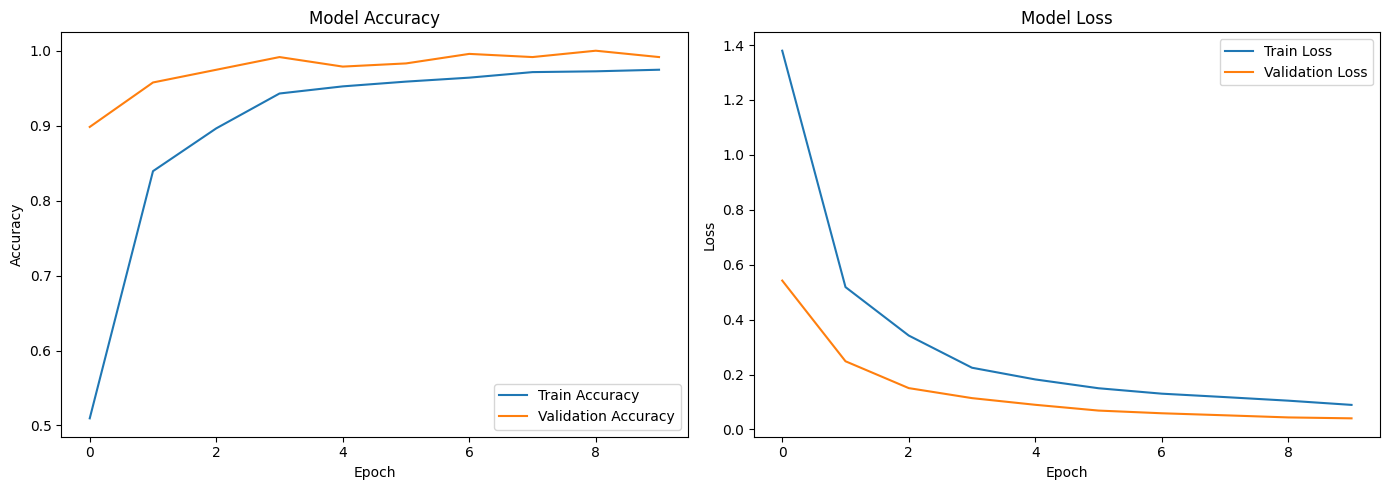

In [42]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()

plt.tight_layout()
plt.show()

**Prediction**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step


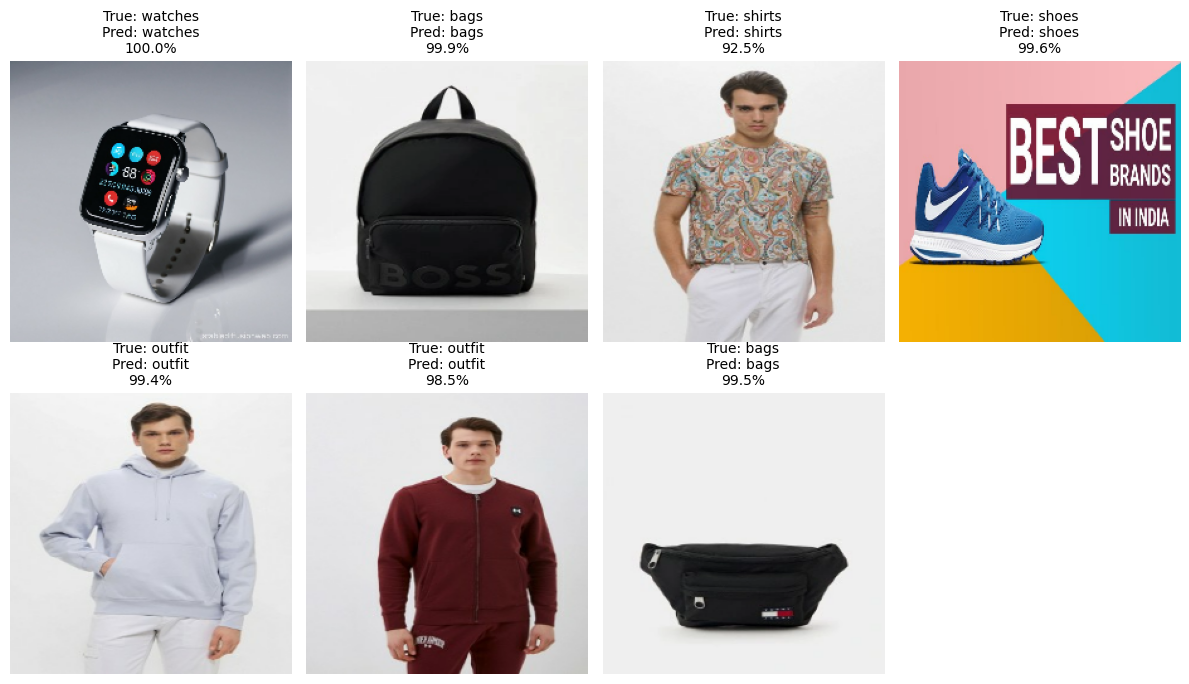

In [46]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 7))

for images, labels in val_ds.take(1):
    predictions = model.predict(images)

    for i in range(7):
        ax = plt.subplot(2, 4, i + 1)

        img = images[i].numpy().astype("uint8")

        true_index = np.argmax(labels[i])
        pred_index = np.argmax(predictions[i])

        true_label = class_names[true_index]
        pred_label = class_names[pred_index]
        confidence = np.max(predictions[i]) * 100

        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"True: {true_label}\nPred: {pred_label}\n{confidence:.1f}%",
            fontsize=10
        )

plt.tight_layout()
plt.show()

**Save Model**

In [47]:
import json

# Save trained model
model.save("/content/drive/MyDrive/resnet50_fashion_model.keras")

# Save class names
with open("/content/drive/MyDrive/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Model and class names saved successfully")

Model and class names saved successfully


**خطوات التشغيل**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import json
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/drive/MyDrive/resnet50_fashion_model.keras"
)

with open("/content/drive/MyDrive/class_names.json", "r") as f:
    class_names = json.load(f)

print("Model loaded successfully")
print(class_names)